# **Clustering Assignment ( Practical)**


## **Q21 Generate synthetic data with 4 centers using make_blobs and apply     K-Means clustering.       Visualize using a  scatter plot**

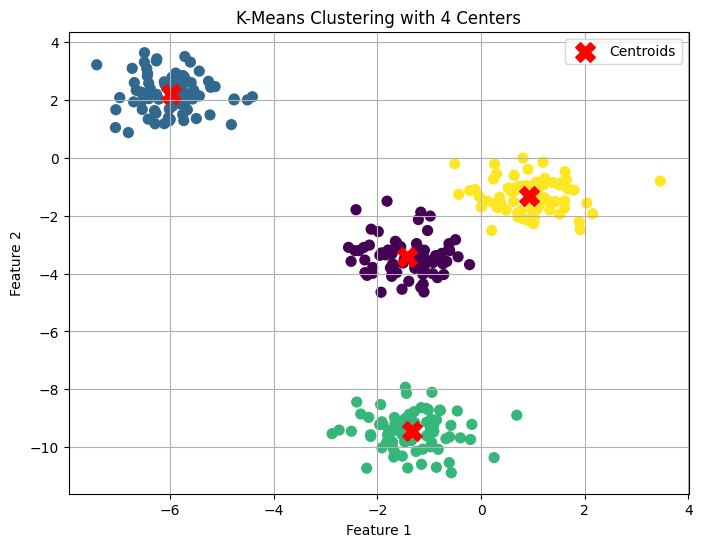

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic data with 4 centers
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=2)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Step 3: Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering with 4 Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## **Q22  Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(X)

# Display the first 10 predicted labels
print("First 10 predicted cluster labels:")
print(labels[:10])

First 10 predicted cluster labels:
[1 1 1 1 1 1 1 1 1 1]


# **Q23 Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot**

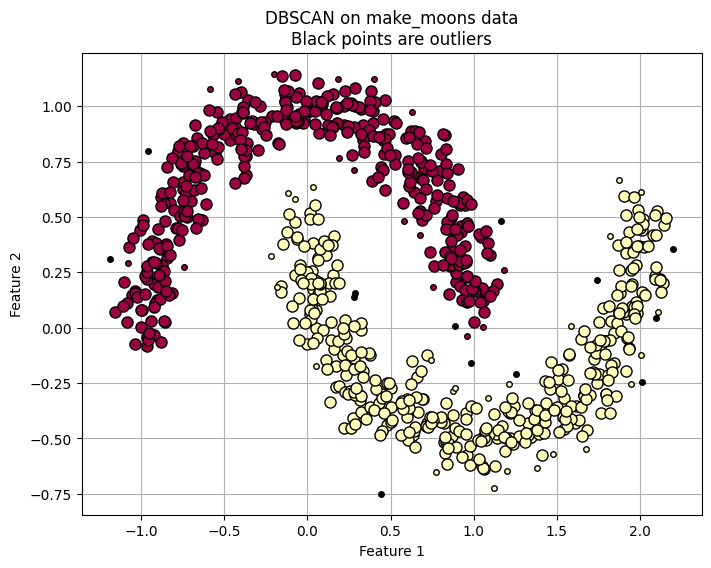

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Generate synthetic data
X, _ = make_moons(n_samples=800, noise=0.1, random_state=5)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=4)
labels = dbscan.fit_predict(X)

# Identify core samples, border points, and outliers
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Plotting
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=8)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=4)

plt.title('DBSCAN on make_moons data\nBlack points are outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# **Q24  Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster**

In [18]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Load the Wine dataset
data = load_wine()
X = data.data

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=2)
kmeans.fit(X_scaled)

# Get cluster labels
labels = kmeans.labels_

# Create a DataFrame for easy analysis
df = pd.DataFrame(X_scaled, columns=data.feature_names)
df['Cluster'] = labels

# Print the size of each cluster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print("Size of each cluster:")
print(cluster_sizes)

Size of each cluster:
Cluster
0    24
1    55
2    48
3    29
4    22
Name: count, dtype: int64


# **Q25  Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result**

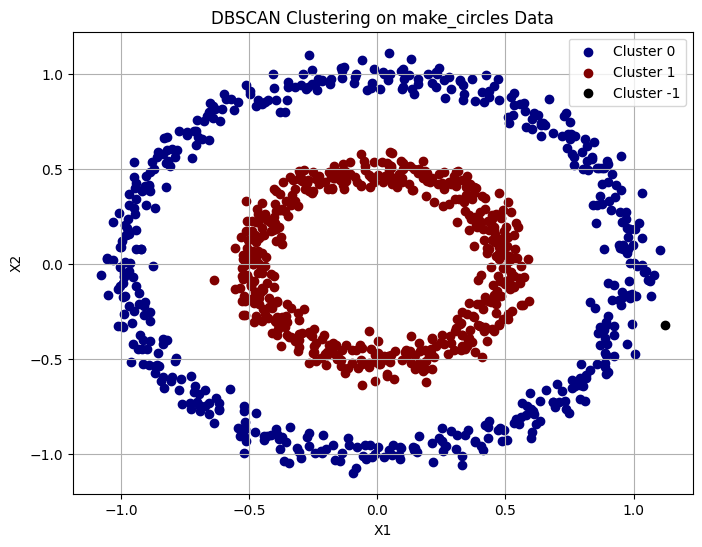

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import numpy as np

# Generate synthetic circular data
X, y = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=2)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
labels = dbscan.fit_predict(X)

# Plotting
plt.figure(figsize=(8, 6))
unique_labels = set(labels)

for label in unique_labels:
    # Black color for noise (label == -1)
    color = 'k' if label == -1 else plt.cm.jet(float(label) / max(unique_labels))
    plt.scatter(X[labels == label, 0], X[labels == label, 1], c=[color], label=f'Cluster {label}')

plt.title("DBSCAN Clustering on make_circles Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()

# **Q26  Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids**

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=2)
kmeans.fit(X_scaled)

# Output the cluster centroids
centroids = kmeans.cluster_centers_

# Convert to DataFrame for better readability
centroid_df = pd.DataFrame(centroids, columns=data.feature_names)
print("Cluster Centroids:")
print(centroid_df)

Cluster Centroids:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     0.255354      0.288335        0.246964   0.143884         0.357431   
1     0.504836      0.395603        0.505787   0.363766         0.469887   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.180195        0.103448              0.13066       0.340118   
1          0.422263        0.418387              0.46928       0.458997   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                0.255916  ...      0.205241       0.320690         0.192421   
1                0.299459  ...      0.480474       0.451074         0.465530   

   worst area  worst smoothness  worst compactness  worst concavity  \
0    0.099434          0.357112           0.148739         0.131423   
1    0.314606          0.498688           0.363915         0.390273   

   worst concave points  worst symmetry  worst fractal dimension  
0   

# **Q27 Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN**

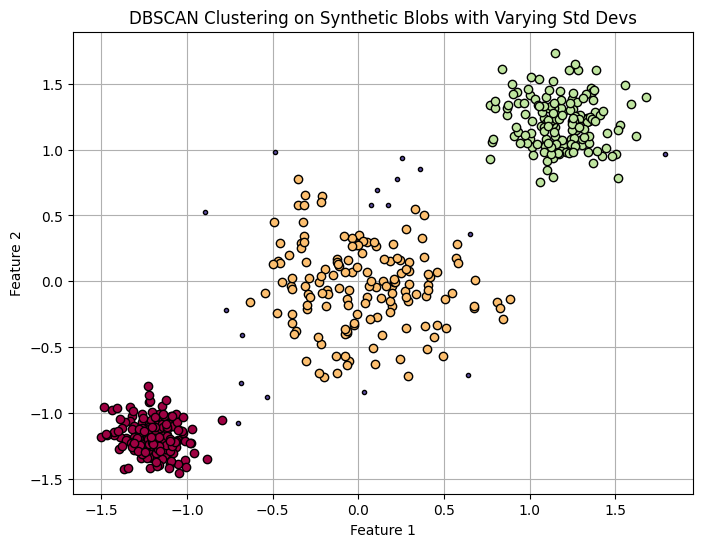

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Generate synthetic data with varying cluster standard deviations
centers = [[-5, -5], [0, 0], [5, 5]]
cluster_std = [0.5, 1.5, 0.8]  # Different std deviations for each cluster
X, y_true = make_blobs(n_samples=500, centers=centers, cluster_std=cluster_std, random_state=2)

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Plot the result
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    class_member_mask = (labels == label)
    xy = X_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=color,
             markeredgecolor='k', markersize=6 if label != -1 else 3)

plt.title("DBSCAN Clustering on Synthetic Blobs with Varying Std Devs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# **Q28  Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means**

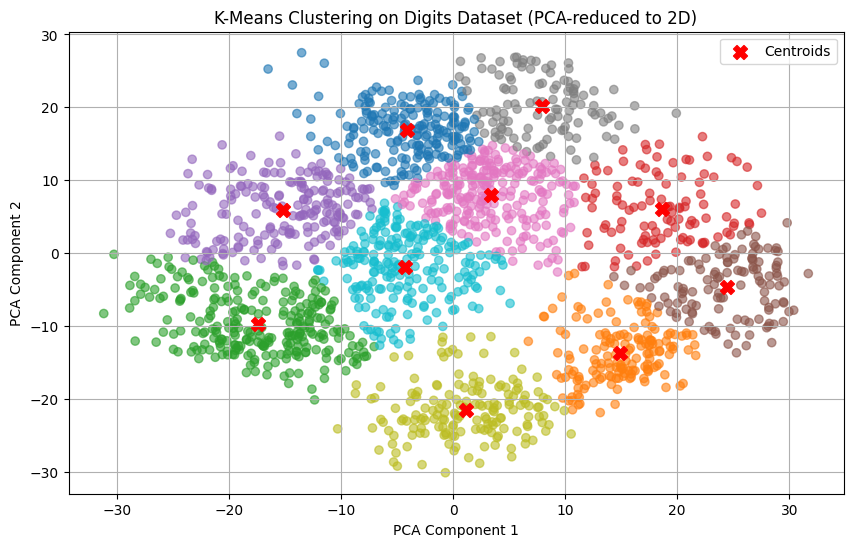

In [26]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply K-Means clustering
n_clusters = 10  # Since digits range from 0-9
kmeans = KMeans(n_clusters=n_clusters, random_state=2)
clusters = kmeans.fit_predict(X_pca)

# Plot the clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.6)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='X', label='Centroids')
plt.title("K-Means Clustering on Digits Dataset (PCA-reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# **Q29  Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart**

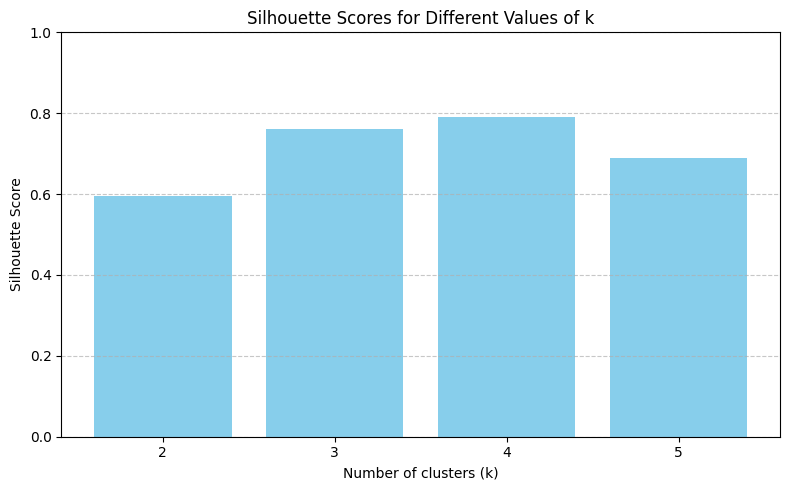

In [27]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 1: Create synthetic data
X, y = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

# Step 2: Compute silhouette scores for k = 2 to 5
k_values = range(2, 6)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Step 3: Plot silhouette scores as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Values of k')
plt.xticks(k_values)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Q30  Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage**

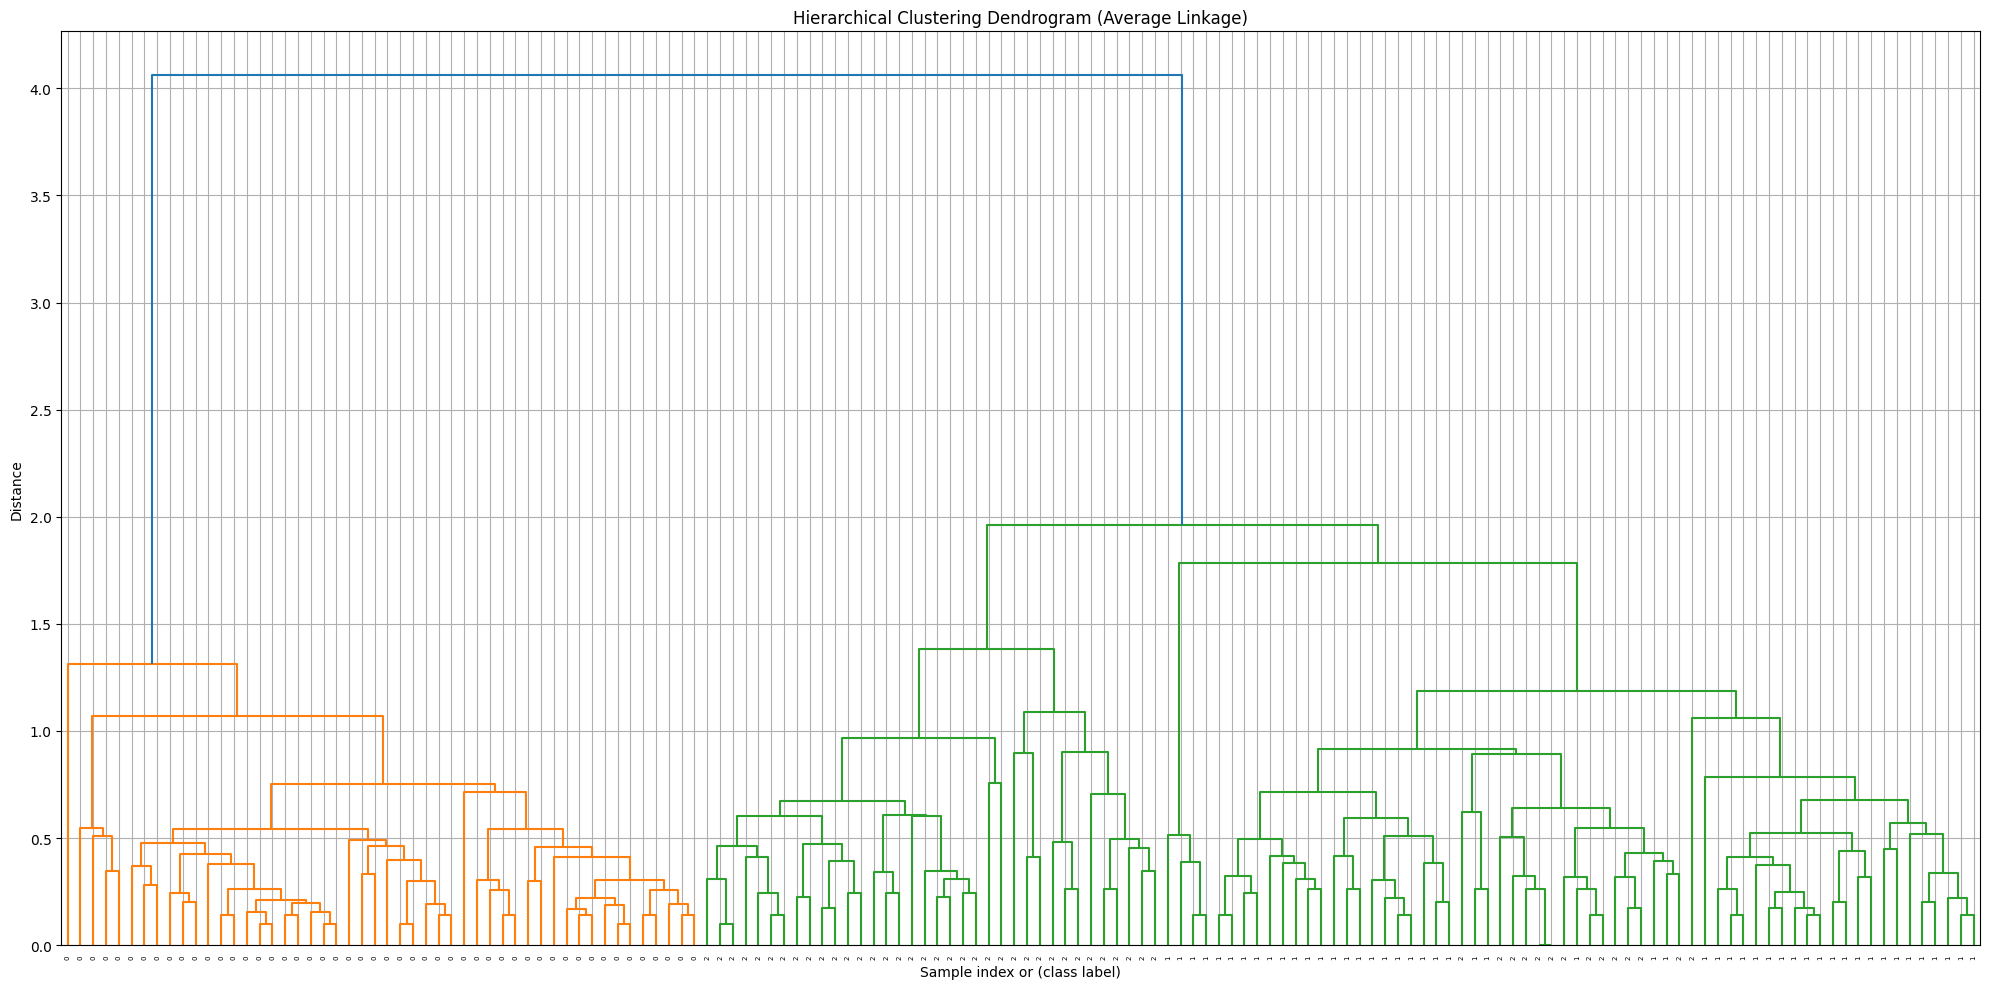

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the Iris dataset
iris = load_iris()
X = iris.data
labels = iris.target

# Perform hierarchical clustering using average linkage
linked = linkage(X, method='average')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           labels=labels,
           distance_sort='ascending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Sample index or (class label)')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Q31  Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries**

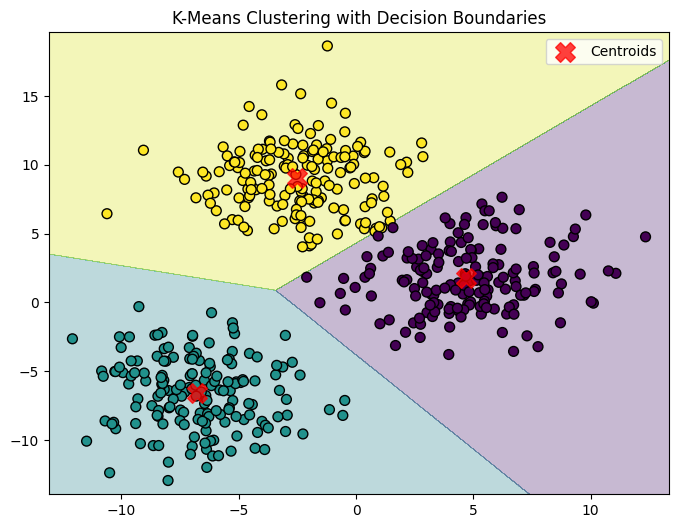

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# Step 1: Generate synthetic data with overlapping clusters
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=2.5, random_state=42)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Step 3: Visualize clusters and decision boundaries
def plot_decision_boundaries(X, model, ax=None, cmap='viridis'):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if ax is None:
        ax = plt.gca()

    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=model.labels_, s=50, cmap=cmap, edgecolor='k')
    centers = model.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
    ax.set_title('K-Means Clustering with Decision Boundaries')
    ax.legend()

# Create plot
fig, ax = plt.subplots(figsize=(8, 6))
plot_decision_boundaries(X, kmeans, ax=ax)
plt.show()

# **Q32  Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results**

<ipython-input-36-b4a5dbb162b0>:27: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters, palette=palette, legend='full', s=60)


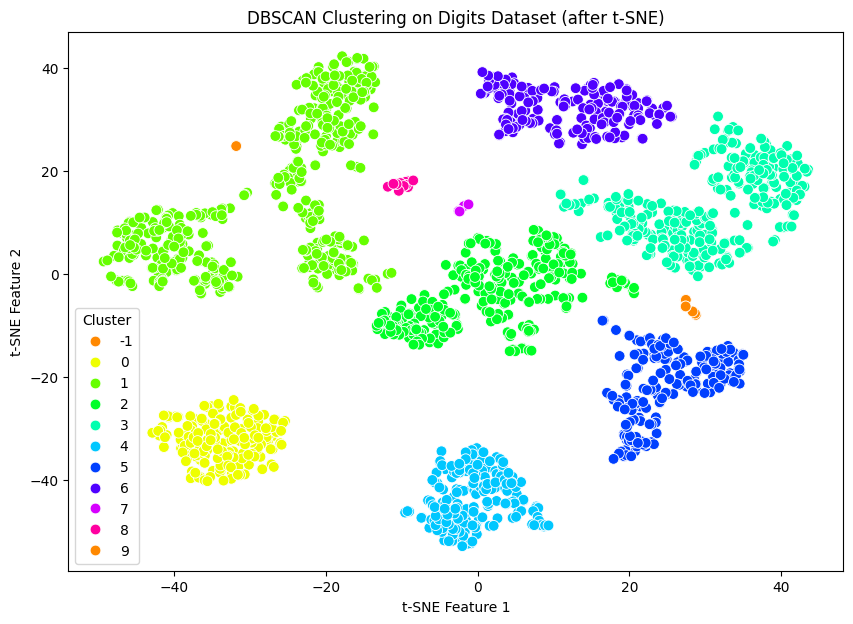

In [36]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target  # Ground truth (not used for clustering, just for comparison)

# Standardize the features
X_scaled = StandardScaler().fit_transform(X)

# Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=2, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=4.5, min_samples=5)
clusters = dbscan.fit_predict(X_tsne)

# Plot the results
plt.figure(figsize=(10, 7))
palette = sns.color_palette("hsv", len(set(clusters)) - (1 if -1 in clusters else 0))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters, palette=palette, legend='full', s=60)

plt.title("DBSCAN Clustering on Digits Dataset (after t-SNE)")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.legend(title='Cluster')
plt.show()

# **Q33 Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result**

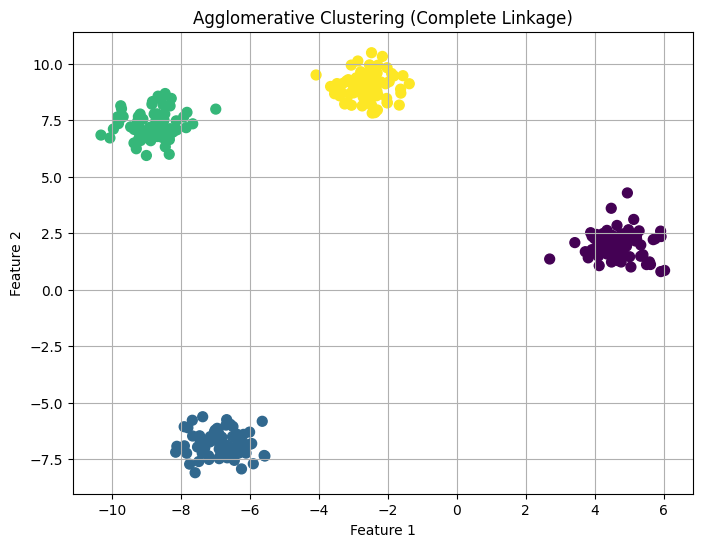

In [37]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Apply Agglomerative Clustering with complete linkage
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='complete')
y_pred = agg_clustering.fit_predict(X)

# Plotting the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=50)
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

# **Q34  Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot**

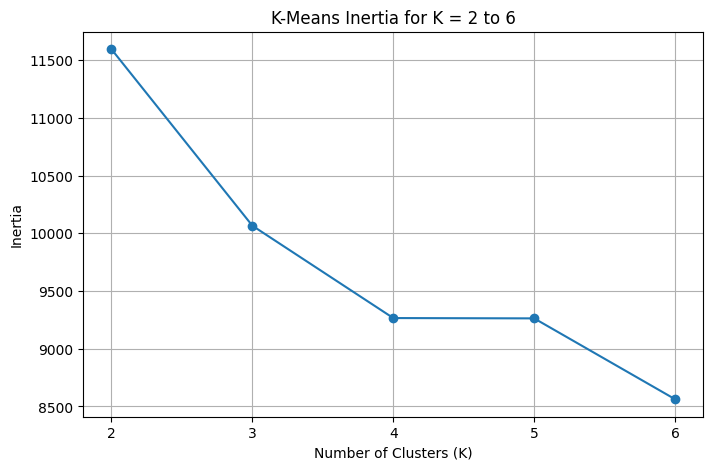

In [38]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = load_breast_cancer()
X = data.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different values of K
inertia_values = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('K-Means Inertia for K = 2 to 6')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# **Q35 Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage**

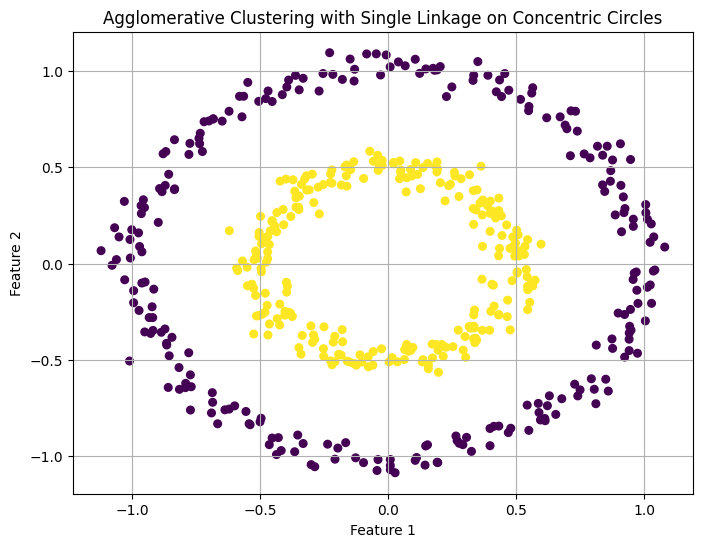

In [40]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic data (concentric circles)
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=2)

# Step 2: Apply Agglomerative Clustering with single linkage
cluster = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = cluster.fit_predict(X)

# Step 3: Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title('Agglomerative Clustering with Single Linkage on Concentric Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# **Q36  Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise**

In [43]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)  # You can tweak eps and min_samples for different results
labels = dbscan.fit_predict(X_scaled)

# Count the number of clusters, excluding noise (-1)
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)

print(f"Number of clusters found (excluding noise): {n_clusters}")

Number of clusters found (excluding noise): 5


# **Q37  Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points**

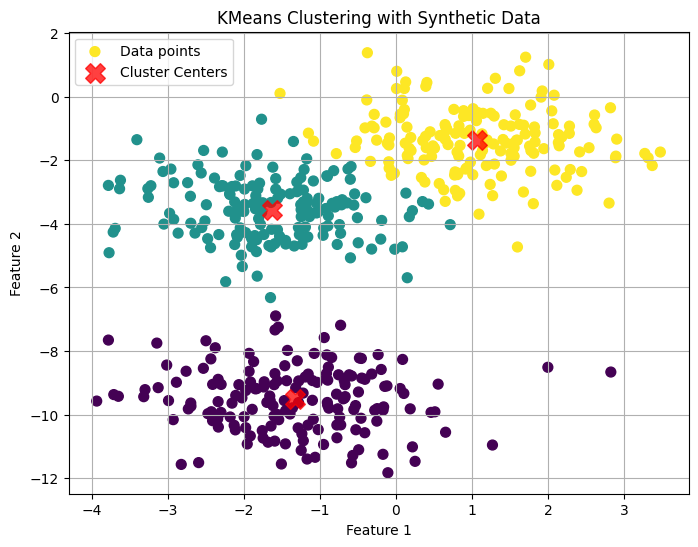

In [45]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data
n_samples = 500
n_features = 2
n_clusters = 3
random_state = 2

X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features, random_state=random_state)

# Apply KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plot the clustered data and cluster centers
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', label='Data points')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Cluster Centers')
plt.title('KMeans Clustering with Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# **Q38  Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise**

In [47]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Standardize the features (important for DBSCAN)
X_scaled = StandardScaler().fit_transform(X)

# Apply DBSCAN
db = DBSCAN(eps=1, min_samples=5)
db.fit(X_scaled)

# Get the labels
labels = db.labels_

# Count the number of noise samples (label == -1)
n_noise = np.sum(labels == -1)

print(f"Number of noise samples: {n_noise}")

Number of noise samples: 3


# **Q39 Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result**

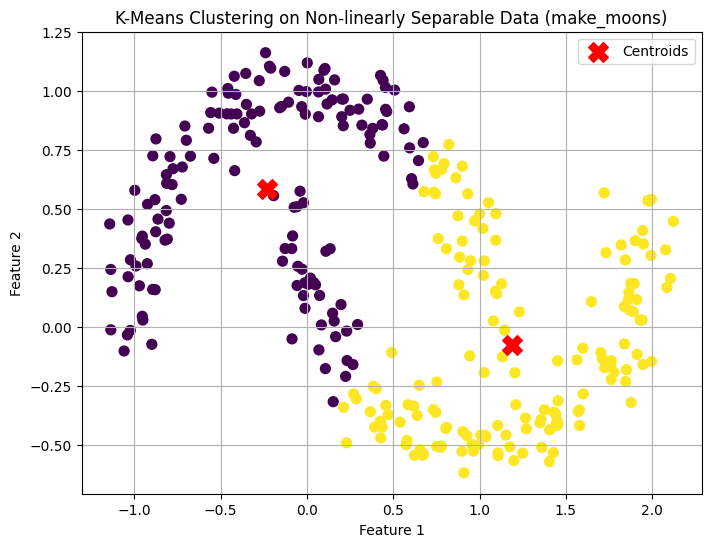

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Step 1: Generate synthetic data
X, y = make_moons(n_samples=300, noise=0.1, random_state=2)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=2)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title("K-Means Clustering on Non-linearly Separable Data (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# **Q40  Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot**

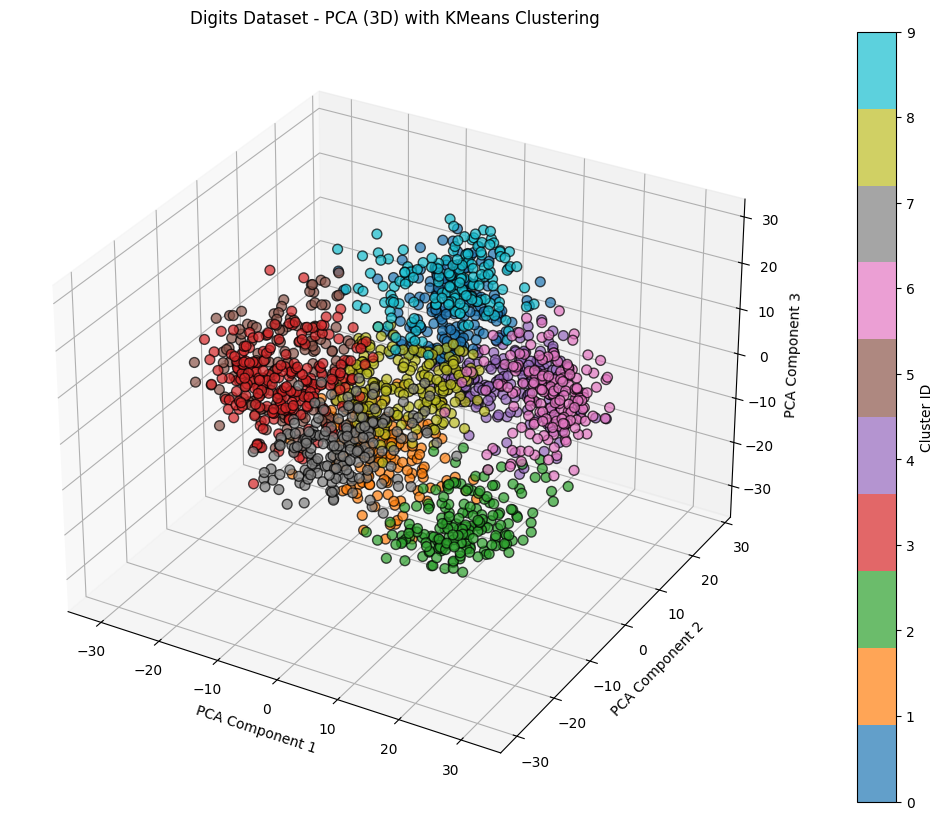

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Step 2: Reduce to 3 components using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Step 3: Apply KMeans clustering
n_clusters = 10  # since we know digits 0-9
kmeans = KMeans(n_clusters=n_clusters, random_state=2, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Step 4: 3D scatter plot
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=clusters, cmap='tab10', s=50, edgecolor='k', alpha=0.7)

ax.set_title("Digits Dataset - PCA (3D) with KMeans Clustering")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# **Q41 Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering**

In [52]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data with 5 centers
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=0.60, random_state=2)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=2)
labels = kmeans.fit_predict(X)

# Step 3: Evaluate clustering with silhouette score
score = silhouette_score(X, labels)

print(f"Silhouette Score for KMeans clustering with 5 clusters: {score:.4f}")



Silhouette Score for KMeans clustering with 5 clusters: 0.7131


# **Q42  Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D**

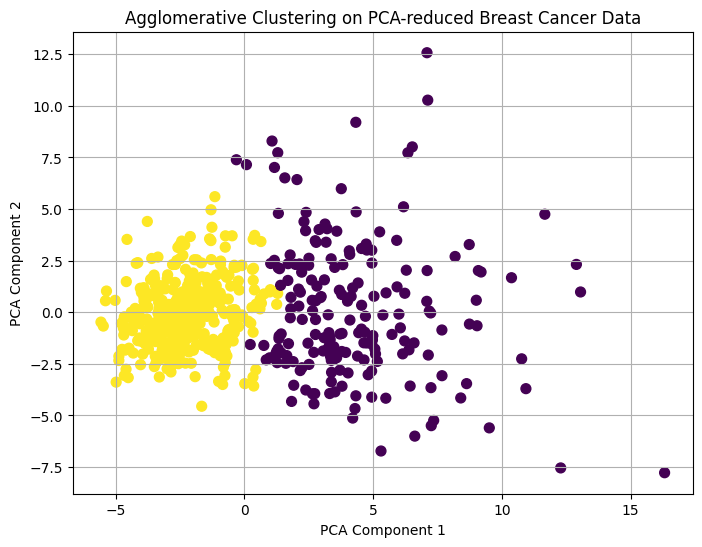

In [53]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target  # Not used for clustering but can be used for reference

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=2)
clusters = agg_clustering.fit_predict(X_pca)

# Step 5: Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title("Agglomerative Clustering on PCA-reduced Breast Cancer Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

# **Q43  Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side**

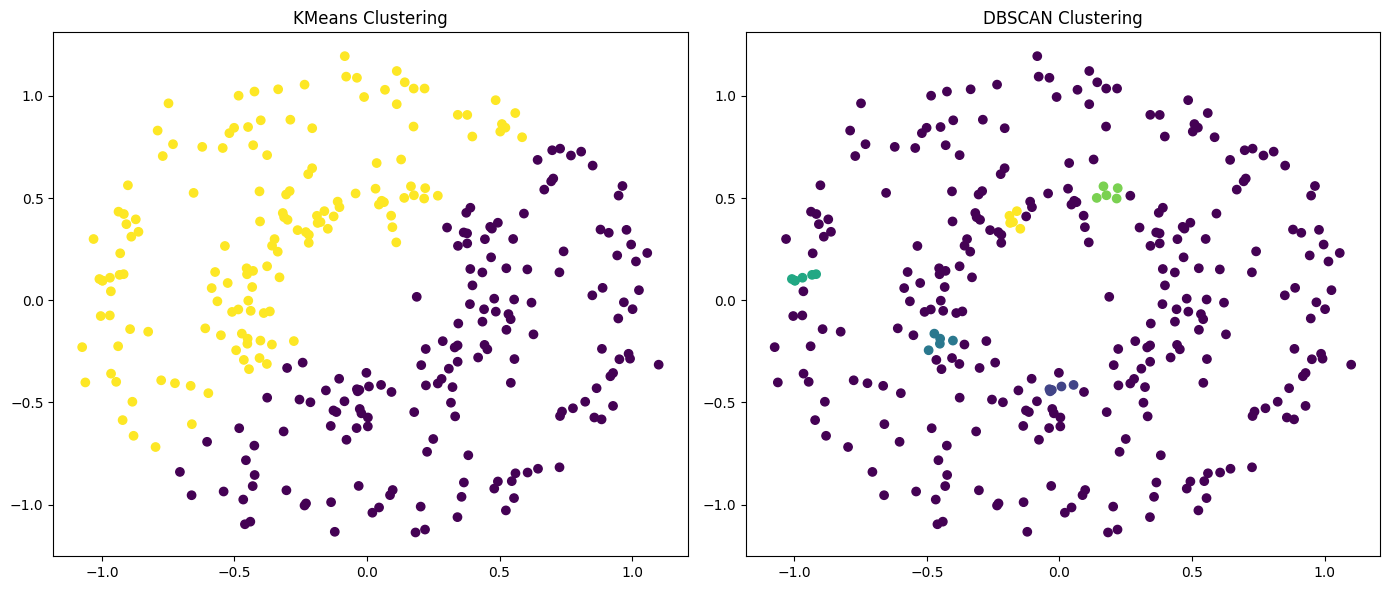

In [54]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Generate noisy circular data
X, _ = make_circles(n_samples=300, noise=0.1, factor=0.5)

# Standardize the data for DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2)
kmeans_labels = kmeans.fit_predict(X)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans Clustering
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
axes[0].set_title('KMeans Clustering')

# DBSCAN Clustering
axes[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
axes[1].set_title('DBSCAN Clustering')

plt.tight_layout()
plt.show()

# **Q44  Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering**

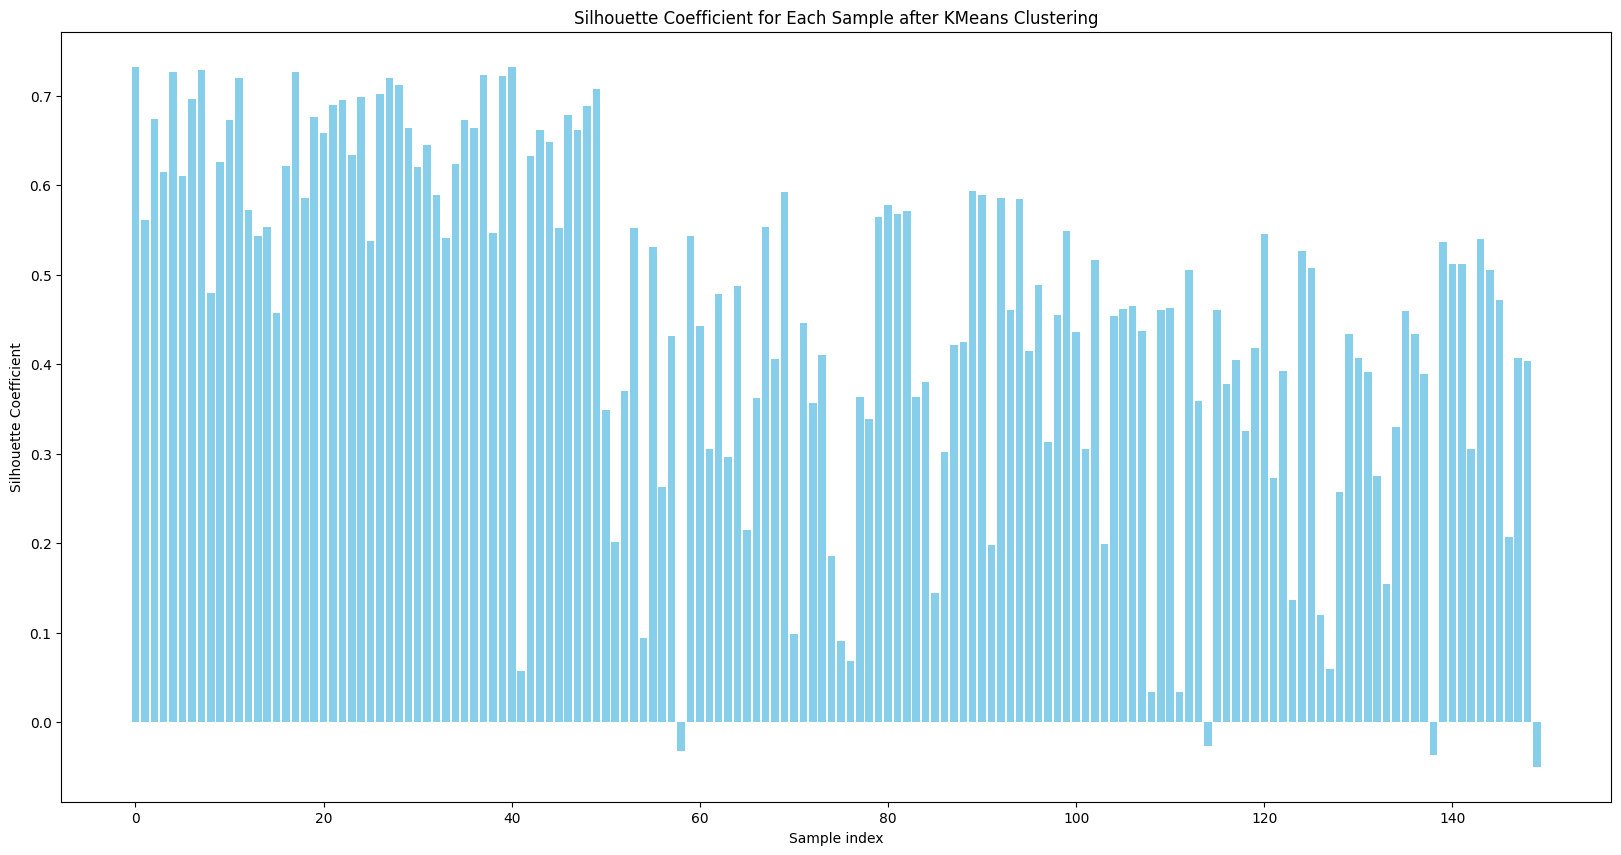

In [56]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data

# Standardize the data (optional but recommended for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=2)
kmeans.fit(X_scaled)

# Get the cluster labels
labels = kmeans.labels_

# Compute the Silhouette Coefficient for each sample
silhouette_vals = silhouette_samples(X_scaled, labels)

# Plot the silhouette coefficients for each sample
plt.figure(figsize=(20, 10))
plt.bar(range(len(silhouette_vals)), silhouette_vals, color='skyblue')
plt.xlabel('Sample index')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient for Each Sample after KMeans Clustering')
plt.show()

# **Q45  Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters**

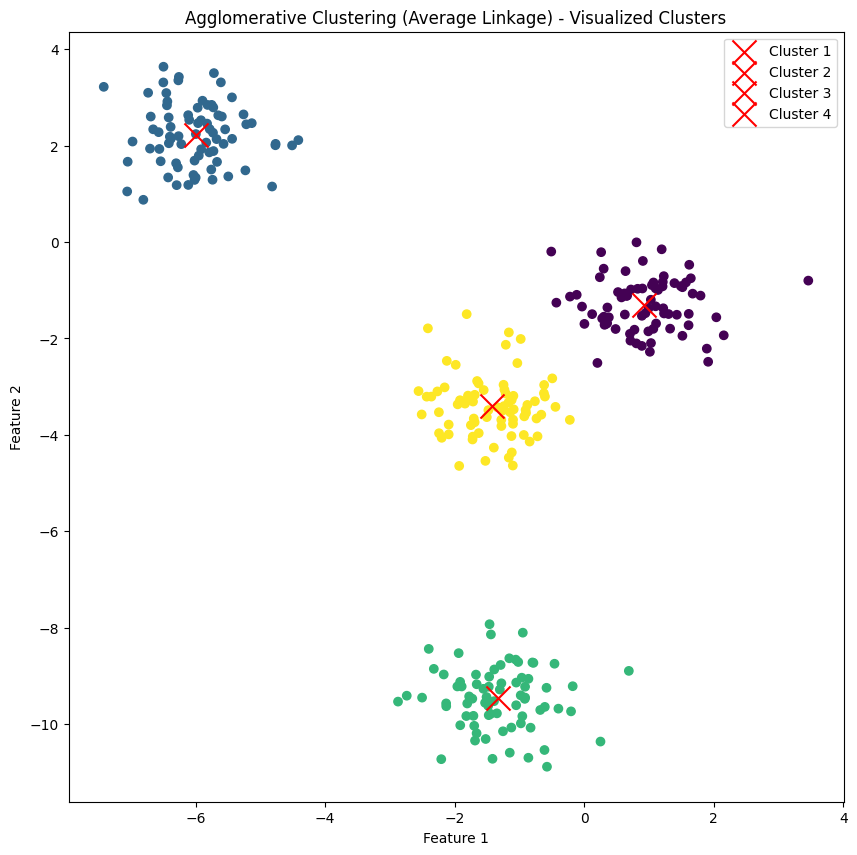

In [57]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic data using make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=2)

# Step 2: Apply Agglomerative Clustering with 'average' linkage
agg_clust = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agg_clust.fit_predict(X)

# Step 3: Visualize the clusters
plt.figure(figsize=(10,10))

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')

# Mark the cluster centers (optional)
for i in range(4):
    center = X[labels == i].mean(axis=0)
    plt.scatter(center[0], center[1], s=300, c='red', marker='x', label=f'Cluster {i+1}')

plt.title("Agglomerative Clustering (Average Linkage) - Visualized Clusters")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# **Q46  Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features)**

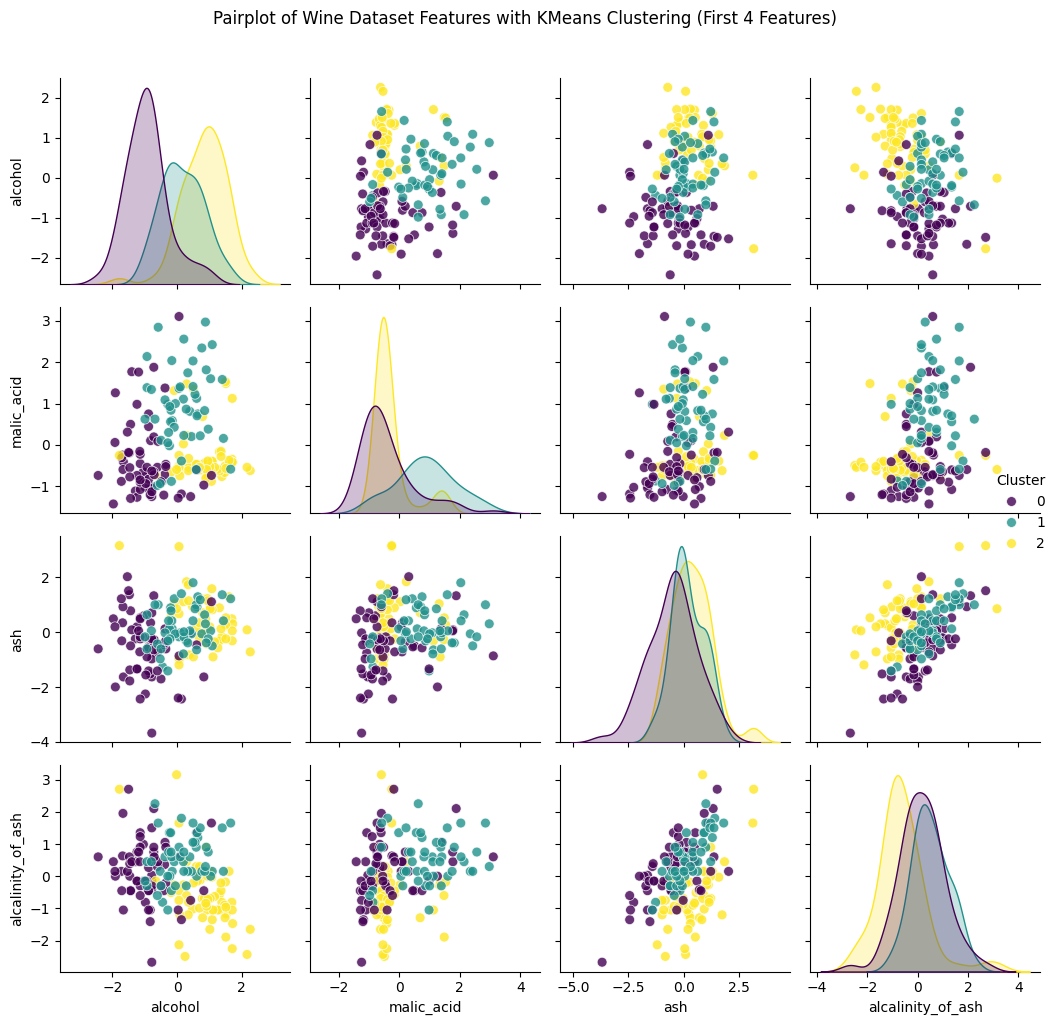

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# Standardize the data (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Using 3 clusters since wine has 3 classes
cluster_labels = kmeans.fit_predict(X_scaled)

# Create a DataFrame with the first 4 features and cluster assignments
df = pd.DataFrame(X_scaled[:, :4], columns=feature_names[:4])
df['Cluster'] = cluster_labels

# Create a pairplot with seaborn
pairplot = sns.pairplot(df, vars=feature_names[:4], hue='Cluster',
                        palette='viridis', plot_kws={'alpha': 0.8, 's': 50})

# Add title
pairplot.fig.suptitle('Pairplot of Wine Dataset Features with KMeans Clustering (First 4 Features)',
                      y=1.02)

plt.tight_layout()
plt.show()

# **Q47 Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count**

In [64]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

# Generate sample data with noise
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=2)

# Add random noise
rng = np.random.RandomState(2)
noise = rng.uniform(low=-10, high=10, size=(30, 2))  # Add 30 noise points
X = np.vstack([X, noise])

# Apply DBSCAN
db = DBSCAN(eps=0.9, min_samples=5)
labels = db.fit_predict(X)

# Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

Estimated number of clusters: 3
Estimated number of noise points: 21


# **Q48  Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters**

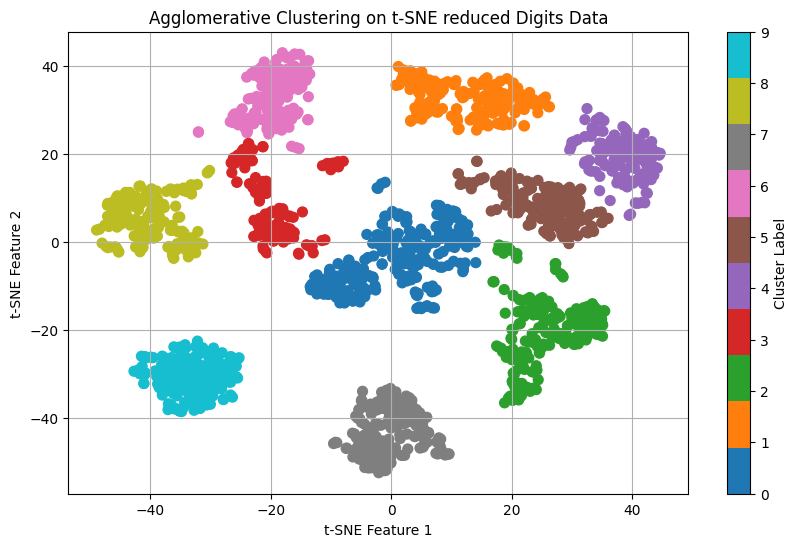

In [65]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target  # True labels (optional, for reference)

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Apply Agglomerative Clustering
n_clusters = 10  # Because digits dataset has 10 classes (0 through 9)
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
clusters = agg_clustering.fit_predict(X_tsne)

# Plot the clustered data
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=50)
plt.title("Agglomerative Clustering on t-SNE reduced Digits Data")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()